### Carga de datos y estadísticas descriptivas

In [0]:
from pyspark.sql.functions import col

# Cargar la tabla limpia desde el catálogo default
df_citas = spark.table("default.citas_pmm_limpio")

# Verificar el número total de registros cargados
print(f"Total de registros para el EDA: {df_citas.count()}")

# Estadísticas descriptivas de variables biométricas y numéricas
columnas_biometricas = ["edad_pac_cita", "peso_kg", "altura_m", "imc", "mins_cit"]
print("\n--- Resumen Estadístico de Variables Biométricas ---")
df_citas.select(columnas_biometricas).summary().display()

# Estadísticas descriptivas de variables financieras
columnas_financieras = ["pago_clie", "pago_aseg", "pago_total"]
print("\n--- Resumen Estadístico de Variables Financieras ---")
df_citas.select(columnas_financieras).summary().display()

Total de registros para el EDA: 10000

--- Resumen Estadístico de Variables Biométricas ---


summary,edad_pac_cita,peso_kg,altura_m,imc,mins_cit
count,10000,10000,10000,10000,10000
mean,41.4262,59.921859999999796,1.5078580000000006,24.21122000000002,37.3245
stddev,26.366157683422486,26.12234717330327,0.31058209536255654,5.8026341576836264,16.8534151883335
min,0,3.5,0.5,13.9,15
25%,18,47.8,1.53,19.3,15
50%,40,65.4,1.62,24.4,30
75%,61,77.7,1.69,28.4,60
max,96,135.3,1.96,45.0,60



--- Resumen Estadístico de Variables Financieras ---


summary,pago_clie,pago_aseg,pago_total
count,10000,10000,10000
mean,19.183780000000013,20.765719999999973,39.9495
stddev,18.62952584568189,19.136854422849076,23.212686889571042
min,0.0,0.0,0.0
25%,6.1,0.0,25.0
50%,14.09,23.57,45.0
75%,25.0,35.95,55.0
max,75.0,67.43,75.0


### Análisis de Distribuciones de Variables Categóricas y Numéricas

In [0]:
import pyspark.sql.functions as F

print("\n--- 1. Extracción de Características Temporales ---")
# Creación de nuevas variables (Feature Engineering básico)
df_citas = df_citas.withColumn("dia_semana", F.dayofweek("fecha_cit")) \
                   .withColumn("mes", F.month("fecha_cit")) \
                   .withColumn("hora_inicio", F.hour("hr_inicio_cit"))

# Volumen de citas por hora del día para identificar horas pico
print("Distribución de Citas por Hora de Inicio:")
df_citas.groupBy("hora_inicio").count().orderBy("hora_inicio").display()

print("\n--- 2. Análisis Bivariado: Ausentismo vs. Factores Operativos ---")

# Tasa de estado de cita cruzada con la Sucursal (Identificar si la ubicación afecta el ausentismo)
print("Estado de Citas por Sucursal:")
df_citas.crosstab("nom_sucursal", "estado_cita").display()

# Tasa de estado de cita cruzada con el Día de la Semana
print("Estado de Citas por Día de la Semana:")
df_citas.crosstab("dia_semana", "estado_cita").display()

print("\n--- Análisis Bivariado: Carga Financiera ---")
# Promedio de facturación total agrupado por Especialidad
# Útil si el objetivo es predecir costos
df_citas.groupBy("especialidad_medica") \
    .agg(
          F.round(F.avg("pago_total"),2).alias("Promedio_Pago_Total"),
          F.round(F.sum("pago_total"),2).alias("Ingreso_Total_Historico")) \
    .orderBy("Promedio_Pago_Total", ascending=False).display()


--- 1. Extracción de Características Temporales ---
Distribución de Citas por Hora de Inicio:


hora_inicio,count
8,947
9,1023
10,986
11,1054
12,1027
13,1034
14,961
15,975
16,1041
17,952



--- 2. Análisis Bivariado: Ausentismo vs. Factores Operativos ---
Estado de Citas por Sucursal:


nom_sucursal_estado_cita,Cancelada,Completada
PMM Brisas del Golf,299,1228
PMM Tocumen,188,798
PMM El Dorado,385,1570
PMM San Francisco,606,2370
PMM Costa del Este,477,2079


Estado de Citas por Día de la Semana:


dia_semana_estado_cita,Cancelada,Completada
7,257,1111
2,280,1156
6,289,1187
4,286,1173
1,267,1169
5,287,1129
3,289,1120



--- Análisis Bivariado: Carga Financiera ---


especialidad_medica,Promedio_Pago_Total,Ingreso_Total_Historico
Neurología,61.97,33525.0
Cardiología,56.77,24920.0
Nefrología,54.31,30520.0
Gastroenterología,50.47,30030.0
Psiquiatría,48.65,28020.0
Radiología,43.71,37070.0
Geriatría,41.28,7100.0
Otorrinolaringología,40.94,35000.0
Dermatología,39.92,35850.0
Urología,37.89,12240.0


In [0]:
# Proporción de citas por estado
print("\n--- Estado de las Citas ---")
df_citas.groupBy("estado_cita").count()\
    .withColumnRenamed("estado_cita", "Estado") \
    .withColumnRenamed("count", "Total de Citas") \
    .orderBy("Total de Citas", ascending=False).display()


# Distribución de citas por Sucursal
print("--- Volumen de Citas por Sucursal ---")
df_citas.groupBy("nom_sucursal").count() \
    .withColumnRenamed("nom_sucursal", "Sucursal") \
    .withColumnRenamed("count", "Total de Citas") \
    .orderBy("Total de Citas", ascending=False).display()


# Distribución de citas por Aseguradora
print("\n--- Volumen de Citas por Aseguradora ---")
df_citas.groupBy("nom_aseguradora").count()\
    .withColumnRenamed("nom_aseguradora", "Aseguradora") \
    .withColumnRenamed("count", "Total de Citas") \
    .orderBy("Total de Citas", ascending=False).display()


# Top 5 de Especialidades Médicas con mayor demanda
print("\n--- Top 5 Especialidades Médicas ---")
df_citas.groupBy("especialidad_medica").count()\
    .withColumnRenamed("especialidad_medica", "Especialidad Médica") \
    .withColumnRenamed("count", "Cantidad de Doctores") \
    .orderBy("Cantidad de Doctores", ascending=False).limit(5).display()


# Top 20 motivos más comunes
print("\n--- Motivos ---")
df_citas.groupBy("motivo_cita").count().orderBy("count", ascending=False).limit(20).display()



--- Estado de las Citas ---


Estado,Total de Citas
Completada,8045
Cancelada,1955


--- Volumen de Citas por Sucursal ---


Sucursal,Total de Citas
PMM San Francisco,2976
PMM Costa del Este,2556
PMM El Dorado,1955
PMM Brisas del Golf,1527
PMM Tocumen,986



--- Volumen de Citas por Aseguradora ---


Aseguradora,Total de Citas
Particular / Sin Seguro,2510
PALIG,1623
MAPFRE Panamá,1569
Seguros ASSA,1518
Compañía Internacional de Seguros (IS),1404
Seguros SURA,1376



--- Top 5 Especialidades Médicas ---


Especialidad Médica,Cantidad de Doctores
Medicina General,927
Fisioterapia,916
Dermatología,898
Oftalmología,898
Otorrinolaringología,855



--- Motivos ---


motivo_cita,count
Control de Presión,329
Control de Acné,325
Rehabilitación de Rodilla,316
Lesión,310
Resfriado,310
Presión Ocular,308
Sinusitis Crónica,308
Evaluación de Lunares,306
Dolor de Muela,305
Limpieza Dental,302


### Correlaciones Visuales - Mapa de Calor

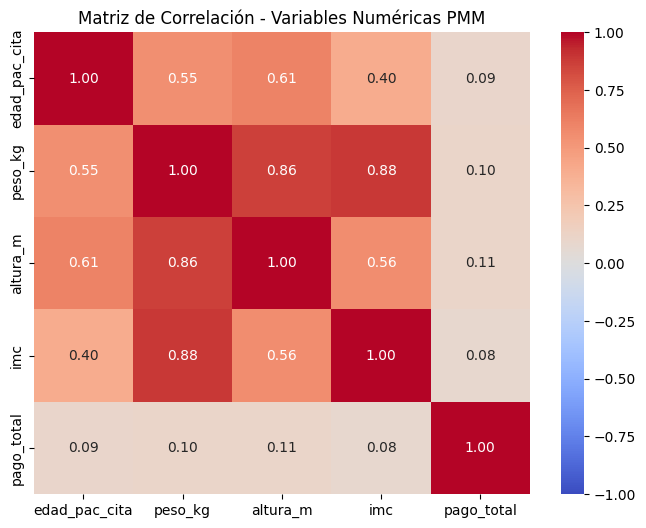

In [0]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar las variables numéricas continuas clave
columnas_num = ["edad_pac_cita", "peso_kg", "altura_m", "imc", "pago_total"]

# Ensamblar las columnas en un vector denso (Requisito de Spark ML)
assembler = VectorAssembler(inputCols=columnas_num, outputCol="features")
df_vector = assembler.transform(df_citas.select(columnas_num))

# Calcular la matriz de correlación de Pearson
matrix = Correlation.corr(df_vector, "features").collect()[0][0]
corr_matrix = matrix.toArray().tolist()

# Convertir a un DataFrame de Pandas para poder usar Seaborn
df_corr = pd.DataFrame(corr_matrix, index=columnas_num, columns=columnas_num)

# Dibujar el mapa de calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación - Variables Numéricas PMM")
plt.show()

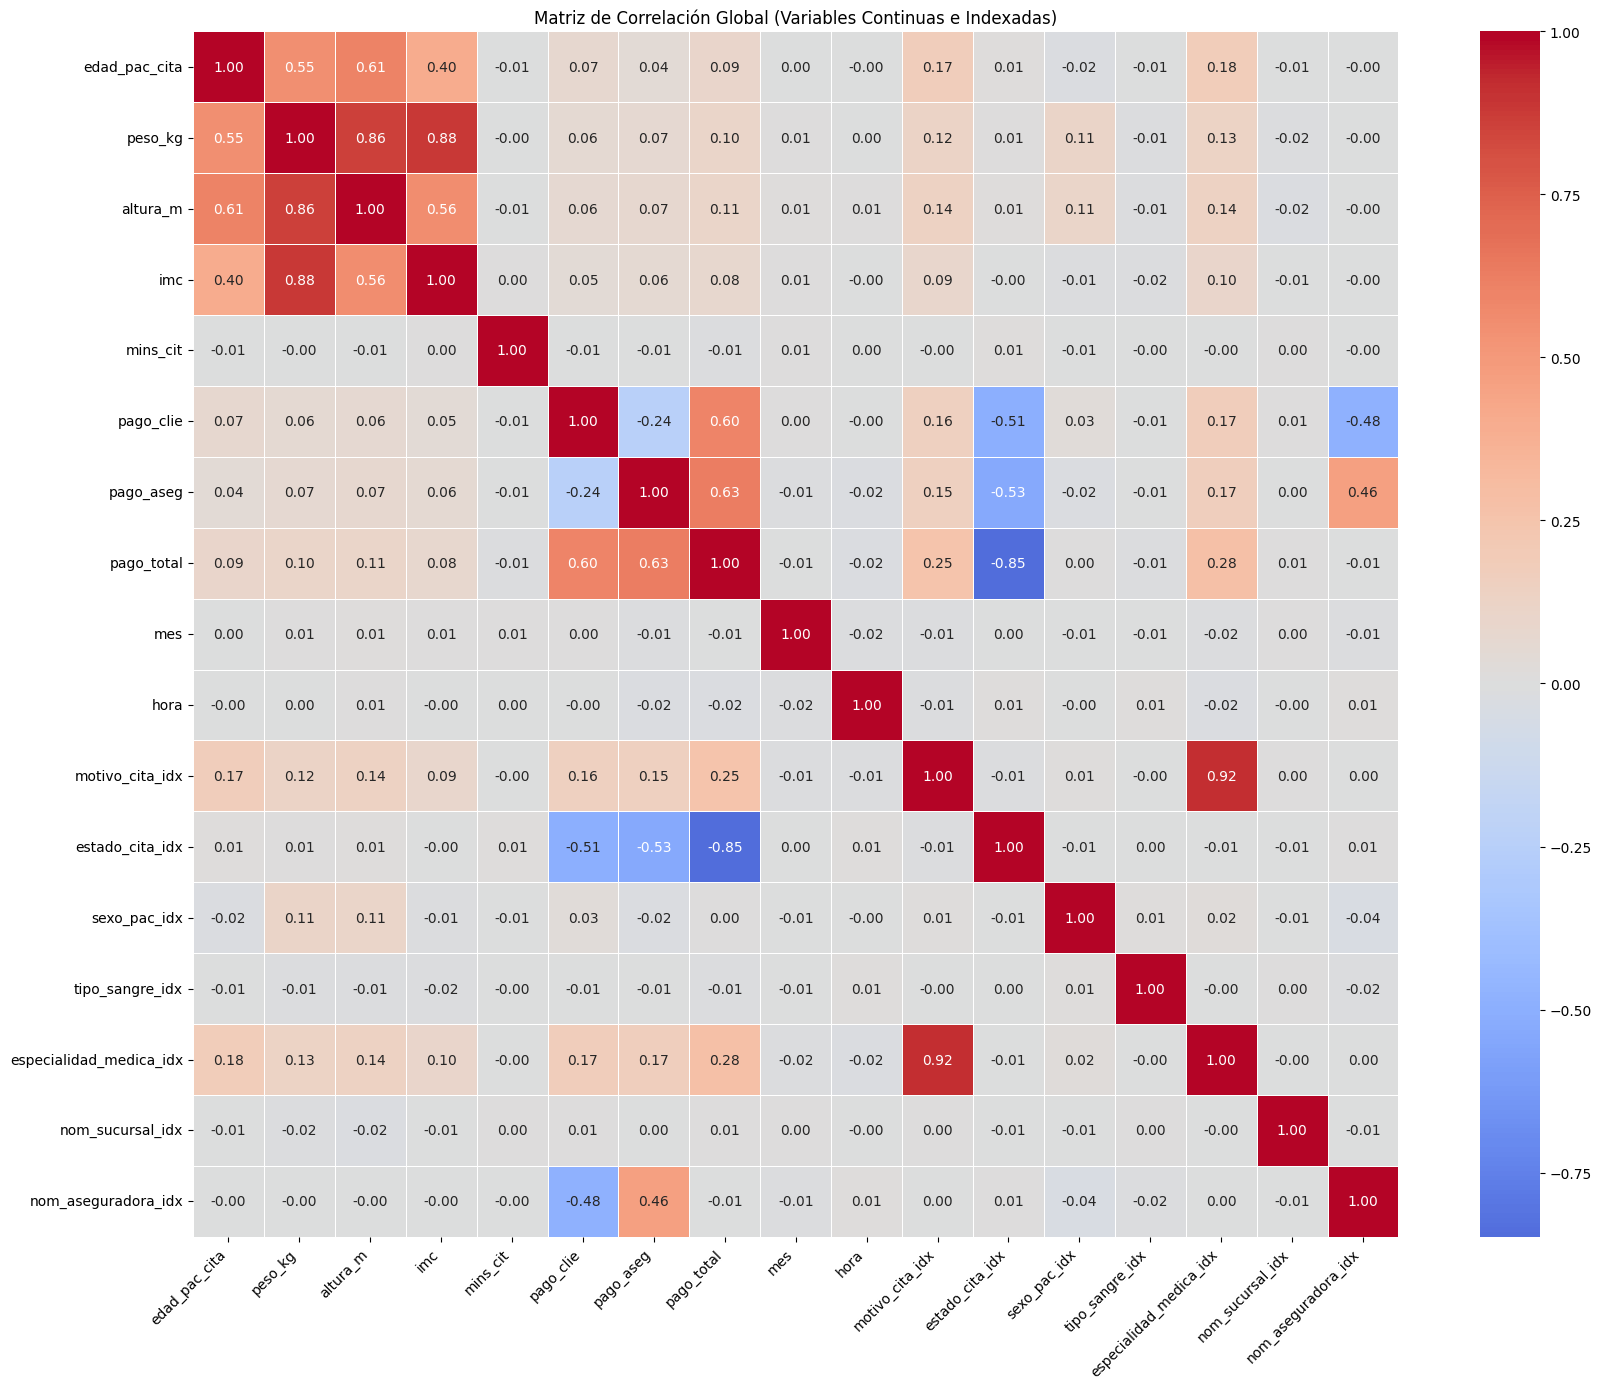

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.ml import Pipeline
import pyspark.sql.functions as F

# 1. Ingeniería de Características: Extraer variables numéricas de las fechas temporales
df_prep = df_citas.withColumn("mes", F.month("fecha_cit")) \
                  .withColumn("hora", F.hour("hr_inicio_cit"))

# 2. Definición de dominios de variables (excluyendo IDs y textos libres si los hubiera)
cols_numericas = ["edad_pac_cita", "peso_kg", "altura_m", "imc", "mins_cit", 
                  "pago_clie", "pago_aseg", "pago_total", "mes", "hora"]

cols_categoricas = ["motivo_cita", "estado_cita", "sexo_pac", "tipo_sangre", 
                    "especialidad_medica", "nom_sucursal", "nom_aseguradora"]

# 3. Codificación de Variables Categóricas (StringIndexer)
# handleInvalid="skip" previene errores si hay valores anómalos o nulos imprevistos
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="skip") for c in cols_categoricas]

# Ejecutar el pipeline de transformación
pipeline = Pipeline(stages=indexers)
df_indexed = pipeline.fit(df_prep).transform(df_prep)

# 4. Consolidación de columnas para la matriz
cols_categoricas_idx = [f"{c}_idx" for c in cols_categoricas]
todas_las_columnas = cols_numericas + cols_categoricas_idx

# Las matrices de correlación requieren datasets sin valores nulos (NaN)
df_clean = df_indexed.select(todas_las_columnas).dropna()

# 5. Vectorización de los datos (Requisito estricto de PySpark MLlib)
assembler = VectorAssembler(inputCols=todas_las_columnas, outputCol="features")
df_vector = assembler.transform(df_clean).select("features")

# 6. Cálculo de la Matriz de Correlación (Pearson)
matriz_spark = Correlation.corr(df_vector, "features").head()[0].toArray()

# 7. Renderizado Visual (Heatmap)
# Se transfiere la matriz matemática a Pandas para utilizar la librería Seaborn
df_corr = pd.DataFrame(matriz_spark, index=todas_las_columnas, columns=todas_las_columnas)

plt.figure(figsize=(18, 14))
sns.heatmap(df_corr, 
            annot=True,          # Cambiar a False si los números saturan la gráfica
            fmt=".2f",           # Redondear a 2 decimales
            cmap="coolwarm",     # Divergencia de colores (rojo positivo, azul negativo)
            center=0, 
            square=True, 
            linewidths=.5)
plt.title("Matriz de Correlación Global (Variables Continuas e Indexadas)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()